# Autoregressive Normalizing Flows Explained

### MATH 637 — Mathematical Techniques in Data Science · Final Project · Spring 2026

**Team Members**

| Name | Email | Degree Program |
|------|-------|----------------|
| Skylar Callis | sjcallis@udel.edu | MSDS; PhD Applied Math |
| Charles Hart | chharles@udel.edu | Undergraduate Physics |
| Sean Hazen | hazen@udel.edu | PhD Math |
| Joeal Bijoy Thomas | joeal@udel.edu | MSDS |

**Instructor:** Dominique Guillot, University of Delaware


**Note for Dominique:** The goal of this project is to create a tutorial for normalzing flow models. It is written for a technical, but non-mathematical, audience. For example, an astrophysicist who wants to use normalizing flows to model parameters of observed astral phnomena (this is a real person I worked with, and I will be sending over the tutorial). In my time working in ML research and development, I've encountered a lot of people who want to use ML for something, but don't really understand how it works or what a model is doing. I've become passionate about bridging that gap; mostly because it allows researchers to build better models and do better science :) I appreciate you being flexible with the modality of our final project. I am planning on refining this a bit more over the summer, and then submitting it to [Towards Data Science](https://towardsdatascience.com/) with my group. I'll be sure to send it to you if we get published :) -Skylar 

---

## Abstract

Normalizing flows are a family of generative models that learn an exact, invertible mapping between a simple base distribution (e.g. a standard Gaussian) and a complex target distribution from which we wish to sample or evaluate likelihoods. Unlike GANs (which give us samples but no density) or VAEs (which give us only a lower bound on the density), normalizing flows give us **both** exact log-likelihoods *and* easy sampling, at the price of architectural constraints required to keep the Jacobian determinant tractable.

In this notebook we walk through:

1. **The mathematical machinery** — the change-of-variables formula, the Jacobian-determinant log-likelihood objective, and what "tractable" means in this context.
2. **An architectural overview** — a framework of autoregressive flows and architecture choices
3. **A from-scratch RealNVP** — coupling layers, alternating masks, density estimation on the two-moons dataset.
4. **A from-scratch MAF** — MADE masking, ordering choices, explicit forward (density) and backward (sampling) passes, timing benchmark, and the theory connection.
5. **A real-data demonstration** — using [Zuko](https://zuko.readthedocs.io/stable/) to fit a MAF to the `sklearn` 8x8 digits dataset with dequantization, sample generation, and density-based anomaly detection.

In [5]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
from sklearn.datasets import make_moons
from sklearn.datasets import load_digits

import matplotlib.pyplot as plt
import math, time
from typing import List, Optional

np.random.seed(42)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import MultivariateNormal
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.9.1


In [4]:
import zuko

## Table of Contents

1. [Introduction & Motivation](#1.-Introduction-&-Motivation)
2. [Mathematical Foundations](#2.-Mathematical-Foundations)\
   2.1 [Probability Refresher](#2.1-Probability-Refresher)\
   2.2 [The Change-of-Variables Formula](#2.2-The-Change-of-Variables-Formula)\
   2.3 [What "Tractable" Means Here](#2.3-What-"Tractable"-Means-Here)\
   2.4 [Composition of Bijections](#2.4-Composition-of-Bijections)\
   2.5 [Training via Maximum Likelihood](#2.5-Training-via-Maximum-Likelihood)
3. [Getting Ready to Code](#3.-Getting-Ready-to-Code)\
   3.1 [An Example Dataset](#3.1-An-Example-Dataset)\
   3.2 [Normalizing Flows Packages](#3.2-Normalizing-Flows-Packages)
4. [Architectures of Autoregressive Flows](#4.-Architectures-of-Autoregressive-Flows)\
   4.1 [Universality of Autoregressive Methods](#4.1-Universality-of-Autoregressive-Methods)\
   4.2 [The Affine Transformer](#4.2-The-Affine-Transformer)
6. [Simple Autoregressive Flows: NICE & RealNVP](#5.-Simple-Autoregressive-Flows:-NICE-&-RealNVP)\
   5.1 [Coupling Layer Conditioner](#5.1-Coupling-Layer-Conditioner)\
   5.2 [Coupling Layer Implementation](#5.2-Coupling-Layer-Implementation)\
   5.3 [RealNVP Model From Scratch](#5.3-RealNVP-Model-From-Scratch)\
   5.4 [Training RealNVP](#5.4-Training-RealNVP)\
   5.5 [Visualising What RealNVP Learned](#5.5-Visualising-What-RealNVP-Learned)
7. [Masked Autoregressive Flows (MAF)](#6.-Masked-Autoregressive-Flows-(MAF))\
   6.1 [Autoregressive Conditioner with MADE](#6.1-Autoregressive-Conditioner-with-MADE)\
   6.2 [MADE Implementation](#6.2-MADE-Implementation)\
   6.3 [MAF Implementation from Scratch](#6.3-MAF-Implementation-from-Scratch)\
   6.4 [Training MAF](#6.4-Training-MAF)\
   6.5 [Visualising What MAF Learned](#6.5-Visualising-What-MAF-Learned)\
   6.6 [Forward vs. Inverse Evaluations: Theory & Timing](#6.6-Forward-vs.-Inverse-Evaluations:-Theory-&-Timing)
8. [Masked Autoregressive Flow on Real Images with Zuko](#7.-Masked-Autoregressive-Flow-on-Real-Images-with-Zuko)\
   7.1 [Loading Digits Data](#7.1-Loading-Digits-Data)\
   7.2 [Dequantization](#7.2-Dequantization)\
   7.3 [Building the Flow with Zuko](#7.3-Building-the-Flow-with-Zuko)\
   7.4 [Training with Zuko](#7.4-Training-with-Zuko)\
   7.5 [Generating Samples with a Trained Model](#7.5-Generating-Samples-with-a-Trained-Model)\
   7.6 [Density-Based Anomaly Detection](#7.6-Density-Based-Anomaly-Detection)
9. [Conclusion & Future Work](#8.-Conclusion-&-Future-Work)
10. [References](#9.-References)

## 1. Introduction & Motivation

### Why generative modeling?

Most supervised machine learning is concerned with the probability of some output given a know input: $p(y|x)$. Generative modeling is more ambitious: we want to learn the joint distribution $p(x)$ itself, so that we can:

- **Sample** new points $x \sim p(x)$ that look like our training data,
- **Evaluate the density** $p(x)$ at any new point — useful for anomaly detection and simulation-based inference,
- **Reason probabilistically** — compute conditionals, marginals, expectations.

### The landscape of deep generative models

| Family | Exact density? | Easy sampling? | Latent interpretable? |
|---|---|---|---|
| **VAEs** (Kingma & Welling, 2014) | [ELBO lower bound](https://en.wikipedia.org/wiki/Evidence_lower_bound) | Yes | Yes (Gaussian latent) |
| **GANs** (Goodfellow et al., 2014) | No | Yes | Only Implicitly |
| **Diffusion models** (Ho et al., 2020) | [ELBO lower bound](https://en.wikipedia.org/wiki/Evidence_lower_bound) | Yes (slow) | Partial |
| **Normalizing flows** | **Yes (exact)** | **Yes** | **Yes (invertible)** |

Normalizing flows are the only family that gives us exact, tractable likelihoods *together* with easy sampling. As Papamakarios et al. (2021) put it in the canonical review: "normalizing flows provide a general mechanism for defining expressive probability distributions, only requiring the specification of a (usually simple) base distribution and a series of bijective transformations."

### Why normalizing flows?

1. **Invertibility = interpretability.** Every layer is a bijection — no information is destroyed. We can map any $x$ back to its unique latent code $z$.
2. **Distributional outputs for scientific ML.** Flows output a full distribution, not a point estimate — crucial for uncertainty quantification and posterior inference.
3. **Image modeling.** Flows define a density everywhere on $\mathbb{R}^d$; they handle dequantized image data in a principled way (see §6.1).

### What are normalizing flows?

The goal of a normalizing flow model is to learn a transform from simple distribution (often a normal or uniform distribution) to a distribution that well represents the data.

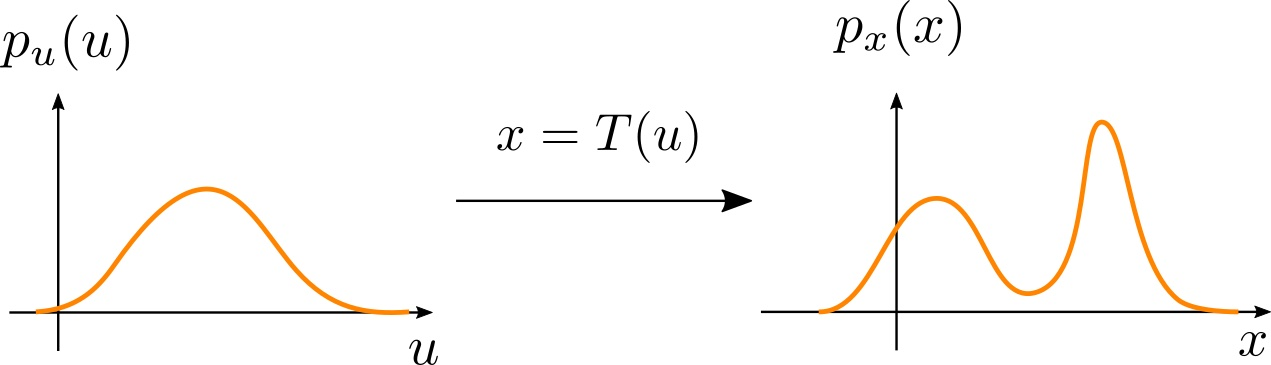

*Figure from [Daniel Daza](https://dfdazac.github.io/02-flows.html)*


We are going to focus on differnt kinds of **autoregressive flows**, since these were one of the first classes of flow to be developed and they remain one of the most popular. Other kinds of flows make different choices on how they model the distribution transformation

## 2. Mathematical Foundations

### 2.1 Probability Refresher

Since we're going to be working with distributions, let's start with a probability review.

[**Random Variable:**](https://en.wikipedia.org/wiki/Random_variable) A measurable function $X : \Omega \to \mathbb{R}^d$ from a sample space to the reals — informally, "a quantity that depends on a random outcome."

[**Probability density function (PDF):**](https://en.wikipedia.org/wiki/Probability_density_function) For an absolutely continuous random variable $X$ on $\mathbb{R}^d$, the PDF $p_X : \mathbb{R}^d \to \mathbb{R}_{\ge 0}$ satisfies

$$\Pr(X \in A) = \int_A p_X(x)\, dx \qquad\text{for any measurable } A.$$

> For those of who who are particularly mathematically minded, note that PDFs are *absolutely continuous with respect to the [Lebesgue measure](https://en.wikipedia.org/wiki/Lebesgue_integral)* on $\mathbb{R}^n$

The PDF is *not* a probability — it is a relative likelihood density. Probabilities arise only from integrating over a set.

### 2.2 The Change-of-Variables Formula

To execute the distribution transformation, we need to be able  perform a change-of-variables. This is the single most important equation in the entire theory of normalizing flows. 


Suppose we have a [diffeomorphism](https://en.wikipedia.org/wiki/Diffeomorphism) (a continuous, differentiable, invertible function with a continuous, differentiable inverse)  $f : \mathbb{R}^d \to \mathbb{R}^d$ and $X = f(Z)$. Then:

$$\boxed{\;\log p_X(x) \;=\; \log p_Z\bigl(z\bigr) \;-\; \log\bigl|\det J_f(z)\bigr|,  \quad z=f^{-1}(x).\;}$$

where $J_f(z) = \partial f/\partial z$ is the Jacobian matrix. $|\det J_f|$ is the local volume scaling factor — it tells us how much $f$ stretches or compresses space around $z$. Probability mass is conserved: if $f$ stretches a region by $|\det J_f|$, the density drops by the same factor.

#### Change of Variables in Action

We'll do a quick demo of this formula in action. Let's define a non-linear bijection $f(z) = z^3/3 + z$, whose derivative $f'(z) = z^2 + 1$ is always positive. This guarantees that $f$ is a valid, globally invertible map. 

We then draw 50,000 samples $Z \sim \mathcal{N}(0,1)$, and push them through $f$ to obtain samples of $X = f(Z)$. WE will also independently compute the *analytic* density of $X$ via the change-of-variables formula:

$$p_X(x) = p_Z(f^{-1}(x))\,/\,|f'(f^{-1}(x))|$$

evaluating the numerical inverse with a root-finder.

We then plot both a histrogram of our actual samples of $X$ and our analytic prediction for the probability density.

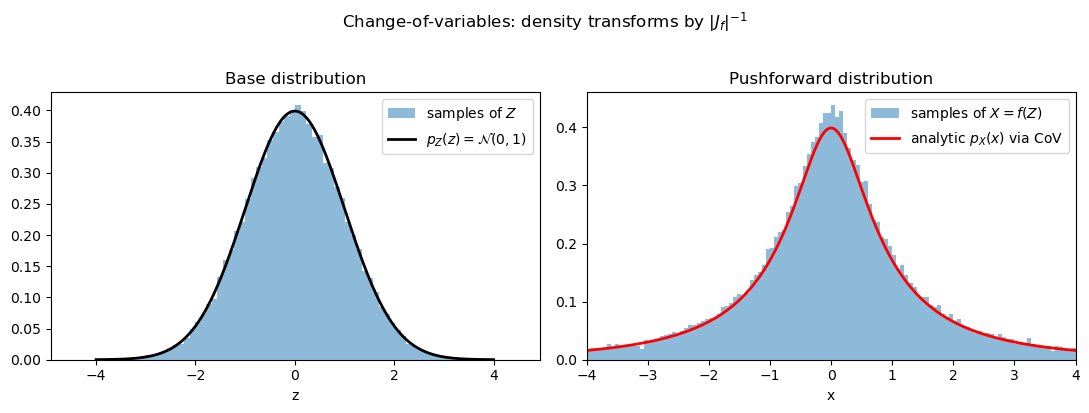

In [4]:
# Sanity check: verify the change-of-variables formula numerically in 1D.
# f(z) = z^3/3 + z — a non-linear bijection with tractable derivative.

def f(z):    return z**3 / 3.0 + z
def df(z):   return z**2 + 1.0          # |J_f(z)| in 1D; always > 0 so f is monotone
def f_inv(x): return brentq(lambda z: f(z) - x, -10, 10)   # numerical inverse

z_samples = np.random.randn(50_000)
x_samples = f(z_samples)

xs = np.linspace(-4, 4, 400)
p_X = np.array([norm.pdf(f_inv(x)) / df(f_inv(x)) for x in xs])  # change-of-variables formula

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(z_samples, bins=80, density=True, alpha=0.5, label='samples of $Z$')
axes[0].plot(xs, norm.pdf(xs), 'k-', lw=2, label=r'$p_Z(z)=\mathcal{N}(0,1)$')
axes[0].set_title('Base distribution'); axes[0].set_xlabel('z'); axes[0].legend()

axes[1].hist(x_samples, bins=120, density=True, alpha=0.5, range=(-4, 4),
             label='samples of $X=f(Z)$')
axes[1].plot(xs, p_X, 'r-', lw=2, label='analytic $p_X(x)$ via CoV')
axes[1].set_xlim(-4, 4); axes[1].set_title('Pushforward distribution')
axes[1].set_xlabel('x'); axes[1].legend()
plt.suptitle('Change-of-variables: density transforms by $|J_f|^{-1}$', y=1.02)
plt.tight_layout(); plt.show()


The resulting figure has two panels. The **left panel** (base distribution) shows that the samples of $Z$ match the standard-normal PDF exactly — a sanity check that the sampling is correct. The **right panel** (pushforward distribution) overlays the histogram of $X = f(Z)$ samples against the red analytic curve: because $f$ is monotone-increasing and has derivative $> 1$ near zero, it compresses the probability mass toward the origin, producing a distribution that is *taller and narrower* than the original Gaussian. The near-perfect agreement between the histogram and the red curve confirms numerically that the change-of-variables formula is implemented correctly. This is the same formula that every normalizing-flow log-likelihood computation relies on.

### 2.3 What "Tractable" Means Here

We train by maximising log-likelihood, so we need $\log p_X(x)$ millions of times. The bottleneck is $\log|\det J_f|$. For a general $d\times d$ matrix this costs $O(d^3)$ — impossible for images where $d$ can be tens of thousands.

The literature calls a method "**tractable**" if it can computes the log-det in $O(d)$ time.

The key trick used by every flow architecture: engineer $f$ so its Jacobian is **triangular**. The determinant of a triangular matrix is the product of its diagonal entries — $O(d)$.

### 2.4 Composition of Bijections

Now that we have the foundations, we can start to build our transformation. Since the goal of normalizing flows is to have an invertible tranformation, we use [bijections](https://en.wikipedia.org/wiki/Bijection). A single bijection $f$ usually isn't expressive enough. Luckily, a composition of bijections is till a bijection. We **compose** $K$ of them:

$$f = f_K \circ f_{K-1} \circ \cdots \circ f_1.$$

The log-det becomes a sum — cheap:

$$\log\bigl|\det J_f(z)\bigr| = \sum_{k=1}^{K} \log\bigl|\det J_{f_k}(z_{k-1})\bigr|, \qquad z_k = f_k(z_{k-1}).$$

This is the **flow**: data is flowed through $K$ transformations that progressively "normalize" it to a Gaussian — or, in reverse, the Gaussian flows to the data.

### 2.5 Training via Maximum Likelihood

We minimise the negative log-likelihood (NLL) per example:

$$\mathcal{L}(\theta) = -\frac{1}{N}\sum_n \Bigl[\log p_Z(f_\theta^{-1}(x^{(n)})) + \log|\det J_{f_\theta^{-1}}(x^{(n)})|\Bigr].$$

Training requires only $f_\theta^{-1}(x)$ and its log-det. Sampling with $f_\theta(z)$ is not needed during training. Different autoregressive flow architectures take advantage of this asymmetry by chosing an $f_{\theta}$ that is easy to evaluate in one direction. You can then chose a model that prioritizes the direction relevant for a given application. Usually, both directions ($f_{\theta}$ and $f_{\theta}^{-1}$) cannot be fast.

### 2.6 Forward vs. Backwards: Density Evaluation vs. Sampling

Given the fully invertible structure, the nomenclature around normalizing flows can get confusing. Typically in the literature, the "forward" direction is whichever direction the model prioritizes. We are going to designate density evaluation as the **forward direction** and sampling as the **backwards direction**. This is because the models train using density evaluation, and `PyTorch` typically calls that the "forward" method. Perhaps unfortunately, the mathematical convention for that direction is $f^{-1}$, as we described above.

| Operation | Direction | Computes |
|-----------|-----------|-------|
| **Density Evaluation (Training)** | Forward: $x \to z = f^{-1}(x)$ | $f^{-1}$ and $\log|\det J|$ |
| **Sampling** | Backwards/Inverse: $z \to x = f(z)$, $z\sim p_Z$ | $f$ only |

## 3. Getting Ready to Code

### 3.1 An Example Dataset

Before we dive into some specific flow architectures, let's set up some data we can train them on. We us the `two-moons` dataset from `sklearn`. This data is an excellent demonstration of the power of normalizing flows because
- is bimodal (a Gaussian can't represent it),
- has curved support (a linear flow can't represent it),
- but is low-dimensional enough that we can plot every diagnostic we want.

Training data shape: torch.Size([20000, 2])


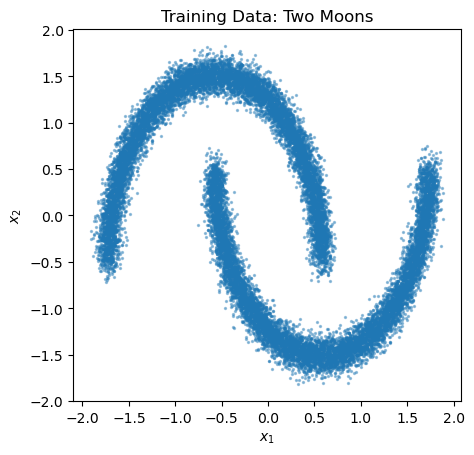

In [7]:
def sample_moons(n):
    X, _ = make_moons(n_samples=n, noise=0.05)
    X = X.astype(np.float32)
    X = (X - X.mean(0)) / X.std(0)   # standardise: makes N(0,I) a good base
    return torch.from_numpy(X)

X_train = sample_moons(20_000)
print(f'Training data shape: {X_train.shape}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_train[:, 0], X_train[:, 1], s=2, alpha=0.4)
ax.set_title('Training Data: Two Moons')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.set_aspect('equal')
plt.show();

### 3.2 Normalizing Flows Packages

There are a lot of different Python packages you can use to build normalizing flow models. We're going to use [PyTorch](https://pytorch.org/) to make our models from scratch, so you can see all the mechanisms under-the-hood. It also means all of the models we devlop will use `torch` functions for their training loop.  We're not going to focus on how that is set up; PyTorch has a tutorial of it [here](https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html). 

In real world applications, you probably want something off-the-shelf that has been built for efficiency, rather than our implementations. Below are a few differnt packages that have pre-built normalizing flows:


> [Pyro](https://pyro.ai/) utilizes PyTorch to calculate probabilistic models. It is a universal Programmable Probability Language (PPl) that mainly uses stochastic variable inference. This basically converts probability computations into optimization problems by evaluating stochastic gradient descent, with PyTorch's help. Pyro has many functions and utilities, including the capabilites to build generative models. Pyro is commonly used for variational autoencoder models, and you can also use it to build normalizing flows. Pyro also extends the univariate bijective transformations present in Pytorch include more learnable univariate and multivariate transformations. 
>
> [Zuko](https://zuko.readthedocs.io/stable/) was specifically designed for normalizing flows on top of PyTorch. Zuko includes modules to build your own normalizing flow architectures, as well as some well-known architectures that come pre-implemented in the `zuko.flows` module (including MAF, NICE, NSF, and CSF--more on those later). Pyro is able to recognize distrobutions built by Zuko with `ZukoToPyro` ([link](https://docs.pyro.ai/en/stable/contrib.zuko.html)). **When we use off-the-shelf models, they will be from Zuko.**
>
> There are other normalizing flows packages in Python, such as [nflows](https://github.com/bayesiains/nflows) and [frEIA](https://pypi.org/project/FrEIA/); although, these libraries are older and less maintained than libraries like Zuko. The `nflows` specifically is able to build standard flows, autoregressive flows, and RealNVP models. We will not use either of these here.

## 4. Architectures of Autoregressive Flows

We're going to focus on autoregressive flows for the rest of this tutorial. They were some of the first flows developed, and remain an overwhemlingly popular choice. The framework put forth in Papamakarios et al. (2021) proposes that every autoregressive-style flow is specified by two choices:

1. **The transformer** — the per-dimension bijection (affine, spline, integration-based, ...)
2. **The conditioner** — how the transformer parameters for dimension $i$ depend on $x_1,\dots,x_{i-1}$ (RNN, masked NN, coupling, ...)

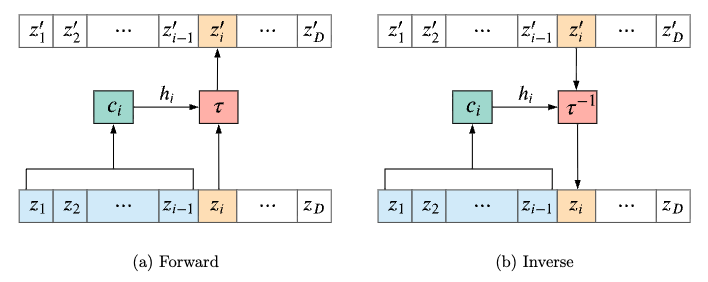

*Figure is Figure 3 in Papamakarios et al. (2021), where $\tau$ is the transformer and $c_i$ is the conditioner for dimension $i$*

### 4.1 Universality of Autoregressive Methods

Before we fully develop some autoregressive models, we should comment on if these are good models to be developing. That creates a natural question: can autoregressive normalizing flows learn *any arbitrary distribution*? In other words, are they universal approximators?

#### Measuring Distribution Agreement

There are many differnt methods to measure distribution agreement. One popular choice is the [**KL Divergence**](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence). If $p(x)$ and $q(x)$ are two probability density functions associated to distributions $\mathcal{P}$ and $\mathcal{Q}$ respectively, then 
$$\mathcal{D}_{KL}(\mathcal{P}||\mathcal{Q})=\int p(x) \log\left(\frac{q(x)}{p(x)}\right)dx.$$

We note that $\mathcal{D}_{KL}(\mathcal{P}||\mathcal{Q})=0$ if and only if $\mathcal{P}=\mathcal{Q}$. In particular, we have that, given a sequence of distributions $\{\mathcal{P}_1,\mathcal{P}_2,\dots\}$, then

$$\lim_{n\rightarrow\infty}\mathcal{D}_{KL}(\mathcal{P}_n||\mathcal{Q})=0\Rightarrow \mathcal{P}_n\xRightarrow{D}\mathcal{Q}.$$

In other words, if the KL-Divergence of the sequence when compared to $\mathcal{Q}$ goes to zero, then the sequence of distributions converges to $\mathcal{Q}$.

#### Proving Universality

Given an arbitrary target distribution $p_X$ to model via a normalizing flow, we would like to have theoretical guarantees on a method's convergence in distribution. If such a guarantee exists under reasonable conditions on $p_X$, we refer to the method as *universal*. To prove that a method is universal, it suffices either to show convergence of the particular model with respect to a specific loss criterion on probability distributions. This can be KL Divergence, as discusses above; or another criterion such as the [Reverse KL Divergence](https://towardsdatascience.com/forward-and-reverse-kl-divergence-906625f1df06/) or the [Maximum Mean Discrepancy](https://en.wikipedia.org/wiki/Kernel_embedding_of_distributions#Measuring_distance_between_distributions). 

Alternatively, Kobyzev et al. (2021) showed the following conditions also show universality:
1.  A diffeomorphism $T$ between the base distribution $p_u$ and the target distribution $p_X$ exists under reasonable conditions on $p_X$.
2. Such a function $T$ can be "approximated" by the family of parameterized functions associated with the method.


Assuming that $p_X$ has a probability density function, the following result from Bogachev et al. (2005) guarantees the first condition:
>If $\mu$ and $\nu$ are absolutely continuous [Borel probability measures](https://en.wikipedia.org/wiki/Borel_measure) on $\mathbb{R}^D$ , then there exists an increasing triangular transformation $T : \mathbb{R}^D \rightarrow \mathbb{R}^D$ , such that $\nu = T\mu$ almost surely.

Note that $T$ being triangular (i.e. $(Tx)_j$ depends only on $x_i$, $i\leq j$) makes the determinant of its Jacobian
$$\det J(T)=\prod_{i=1}^D\frac{\partial T}{\partial x_i}.$$

#### Universal Methods

Hence, for a given method, we only have to check the second condition from Kobyzev et al. (2021). Broadly, autoregressive ﬂows are universal approximators as long asthe transformer and the conditioner are ﬂexible enough to represent any function arbitrarily well (Papamakarios et al., 2021). So far, the following autoregressive methods have been specifically proven as universal:

- Coupling Flows: NICE, RealNVP (developed by Dinh et al. 2014 & 2016; proven by Draxler et al., 2024)
     - Affine Transformer, Coupling Conditioner
- Neural Autoregressive Flows (developed and proven by Huang et al., 2018)
     - Neural Network Transformer, arbitrary conditioner
- Sum-of-Squares Polynomial Autoregressive Flows (developed and proven by Jaini et al., 2019)
     - Sum-of-Squares Polynomial Transformer, arbitrary conditioner

> We'd also like to note that *Residual Flows* (developed by Chen et al., 2019; proven by Kong & Chaudhuri, 2021) have also been proven as a universal method. However, these are not a type of autoregressive flow.

Now, we will proceed with developing some normalizing flows.

### 4.2 The Affine Transformer

All of the autoregressive models we're going to examine use a simple affine transformer. In the forward direction, 

$$\tau_{aff}( c_i(x^{(1)}, ... x^{(i-1)}), x^{(i)} ) = \alpha_i x^{(i)} + \beta_i$$

where the conditioner determines the parameters: $c_i(x^{(1)}, ... x^{(i-1)} ) = (\alpha_i, \beta_i)$. We know that $\tau_{aff}$ will be invertible as long as $\alpha_i \not=0$. In practice, this is often achieved by using $\tilde{\alpha}_i = e^{\alpha_i}$. The log-det is then very simple to compute:

$$\log|\det J_{f_\theta}(x^{(i)})| = \sum_i \log|\tilde{\alpha}_i| = \sum_i \alpha_i.$$

## 5. Simple Autoregressive Flows: NICE & RealNVP

Dinh et al. made early controbutions to autogressive flows by developing a computationally efficient flow called [NICE](https://arxiv.org/abs/1410.8516) (Dinh et al., 2014). Improvements to NICE created [RealNVP](https://arxiv.org/abs/1605.08803) (2016). Both the transformer and the conditioner for RealNVP are relatively simple to implement by hand.

### 5.1 Coupling Layer Conditioner

NICE and RealNVP introduced, and subsequently refined, coupling layers. They are one of the simplest and most widely used flow primitives.

**The idea:** Split the input $x \in \mathbb{R}^d$ into two halves $x = (x_A, x_B)$ along a fixed mask. Define

$$
\begin{aligned}
y_A &= x_A,\\
y_B &= x_B \odot \exp\bigl(s_\theta(x_A)\bigr) + t_\theta(x_A),
\end{aligned}
$$

where $s_\theta, t_\theta$ are arbitrary neural networks (the **scale** and **translation** networks). Crucially, note that $s_\theta$ and $t_\theta$ depend only on $x_A$, which is passed through unchanged.

The Jacobian of this transformation, computed in the order $(x_A, x_B) \mapsto (y_A, y_B)$, is

$$
J = \begin{pmatrix} I & 0 \\ \frac{\partial y_B}{\partial x_A} & \mathrm{diag}(\exp s_\theta(x_A)) \end{pmatrix},
$$

a **block-triangular** matrix. Its log-determinant is just the sum of the diagonal entries of the lower-right block:

$$
\log|\det J| \;=\; \sum_{i \in B} s_\theta(x_A)_i.
$$

That's $O(d)$, with no need to ever compute $\partial y_B / \partial x_A$.

Since this is a very simple case, the inverse direction is also trivial:

$$
x_A = y_A,\qquad x_B = (y_B - t_\theta(y_A)) \odot \exp(-s_\theta(y_A)).
$$

The catch is that one coupling layer leaves half the variables untouched. We fix this by stacking many layers and alternating which half is the "A" half between layers (so all dimensions get transformed eventually).

### 5.2 Coupling Layer Implementation

In practice, we combine the affine transformer and the coupling conditioner into a single `torch` Module.

In [5]:
class CouplingLayer(nn.Module):
    '''Affine coupling layer (RealNVP). Mask selects pass-through dims.
    Transformer: affine — closed-form inverse, O(d) log-det.
    Conditioner: separate s/t MLPs — fast in both directions.
    '''
    def __init__(self, dim, mask, hidden=64):
        super().__init__()
        self.register_buffer('mask', mask)     # fixed; never trained
        def make_net():
            return nn.Sequential(
                nn.Linear(dim, hidden), nn.ReLU(),
                nn.Linear(hidden, hidden), nn.ReLU(),
                nn.Linear(hidden, dim),
            )
        self.s_net = make_net()
        self.t_net = make_net()
        self.scale_factor = nn.Parameter(torch.zeros(dim))  # learnable scale; starts near identity

    def forward(self, x):
        x_masked = x * self.mask
        s = torch.tanh(self.s_net(x_masked)) * self.scale_factor  # tanh: bounds sigma
        t = self.t_net(x_masked)
        y = x_masked + (1 - self.mask) * (x * torch.exp(s) + t) # affine transformer
        log_det = ((1 - self.mask) * s).sum(dim=1)
        return y, log_det

    def inverse(self, y):
        y_masked = y * self.mask
        s = torch.tanh(self.s_net(y_masked)) * self.scale_factor
        t = self.t_net(y_masked)
        x = y_masked + (1 - self.mask) * ((y - t) * torch.exp(-s))
        return x, -((1 - self.mask) * s).sum(dim=1)


### 5.3 RealNVP Model From Scratch

The RealNVP model is made from a stack of coupling layers. We define both the forward and inverse direction.

In [8]:
class RealNVP(nn.Module):
    def __init__(self, dim, n_layers=8, hidden=64):
        super().__init__()
        self.dim = dim
        masks = []
        for i in range(n_layers):
            m = torch.zeros(dim)
            m[i % 2 :: 2] = 1.0    # alternating masks: ensures all dims get transformed
            masks.append(m)
        self.layers = nn.ModuleList([CouplingLayer(dim, m, hidden=hidden) for m in masks])
        self.register_buffer('base_loc', torch.zeros(dim))
        self.register_buffer('base_cov', torch.eye(dim))

    @property
    def base_dist(self): return MultivariateNormal(self.base_loc, self.base_cov)

    def forward(self, x):    # x -> z  (density direction)
        log_det = torch.zeros(x.size(0), device=x.device)
        z = x
        for layer in self.layers:
            z, ld = layer(z); log_det += ld
        return z, log_det

    def inverse(self, z):    # z -> x  (sampling direction)
        log_det = torch.zeros(z.size(0), device=z.device)
        x = z
        for layer in reversed(self.layers):
            x, ld = layer.inverse(x); log_det += ld
        return x, log_det

    def log_prob(self, x):
        z, log_det = self.forward(x)
        return self.base_dist.log_prob(z) + log_det

    def sample(self, n):
        z = self.base_dist.sample((n,))
        x, _ = self.inverse(z)
        return x

model_rnvp = RealNVP(dim=2, n_layers=8, hidden=64).to(device)
n_params = sum(p.numel() for p in model_rnvp.parameters() if p.requires_grad)
print(model_rnvp)
print(f'\nTotal trainable parameters: {n_params:,}')


RealNVP(
  (layers): ModuleList(
    (0-7): 8 x CouplingLayer(
      (s_net): Sequential(
        (0): Linear(in_features=2, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=2, bias=True)
      )
      (t_net): Sequential(
        (0): Linear(in_features=2, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=2, bias=True)
      )
    )
  )
)

Total trainable parameters: 71,728


### 5.4 Training RealNVP

We train the RealNVP model on our two-moons dataset using a standard PyTorch gradient descent procedure, with `Adam` as the optimizer. We use the average negative log liklihood (NLL) as the loss function, which we defined as part of the RealNVP model. A plot of the NLL over the training epochs shows nice asymptotic convergence.

In [14]:
optimizer_rnvp = optim.Adam(model_rnvp.parameters(), lr=1e-3)  # Adam default lr: well-established for flows
n_epochs = 1000
batch_size = 512

X_train_dev = X_train.to(device)
losses_rnvp = []
for epoch in range(n_epochs):
    idx = torch.randint(0, len(X_train_dev), (batch_size,), device=device)
    loss = -model_rnvp.log_prob(X_train_dev[idx]).mean()
    optimizer_rnvp.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(model_rnvp.parameters(), max_norm=5.0)  # clip: prevents NaN from exploding Jacobians
    optimizer_rnvp.step()
    losses_rnvp.append(loss.item())
    if epoch % 100 == 0 or epoch == n_epochs - 1:
        print(f'Epoch {epoch:4d} | NLL = {loss.item():.4f}')


Epoch    0 | NLL = 2.9086
Epoch  100 | NLL = 2.1064
Epoch  200 | NLL = 1.3458
Epoch  300 | NLL = 1.3055
Epoch  400 | NLL = 1.2251
Epoch  500 | NLL = 1.2850
Epoch  600 | NLL = 1.2044
Epoch  700 | NLL = 1.1697
Epoch  800 | NLL = 1.1981
Epoch  900 | NLL = 1.1354
Epoch  999 | NLL = 1.2155


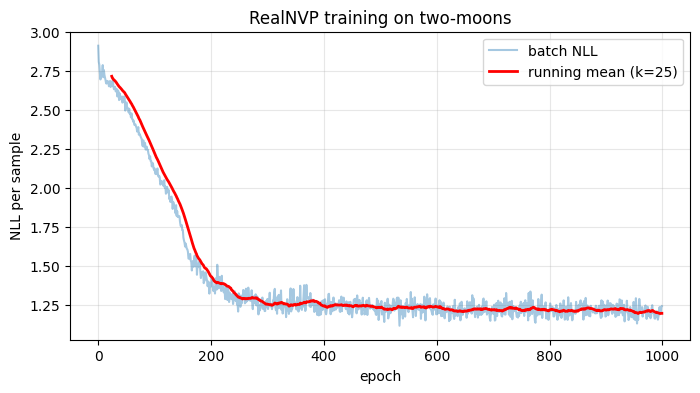

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_rnvp, alpha=0.4, label='batch NLL')
window = 25
smooth = np.convolve(losses_rnvp, np.ones(window)/window, mode='valid')
ax.plot(np.arange(window-1, len(losses_rnvp)), smooth, 'r-', lw=2,
        label=f'running mean (k={window})')
ax.set_xlabel('epoch'); ax.set_ylabel('NLL per sample')
ax.set_title('RealNVP training on two-moons'); ax.legend(); ax.grid(alpha=0.3)
plt.show()


### 5.5 Visualising What RealNVP Learned

Ideally, the RealNVP model has learned a distribution similar to the two-moons. Let's generate some figures.

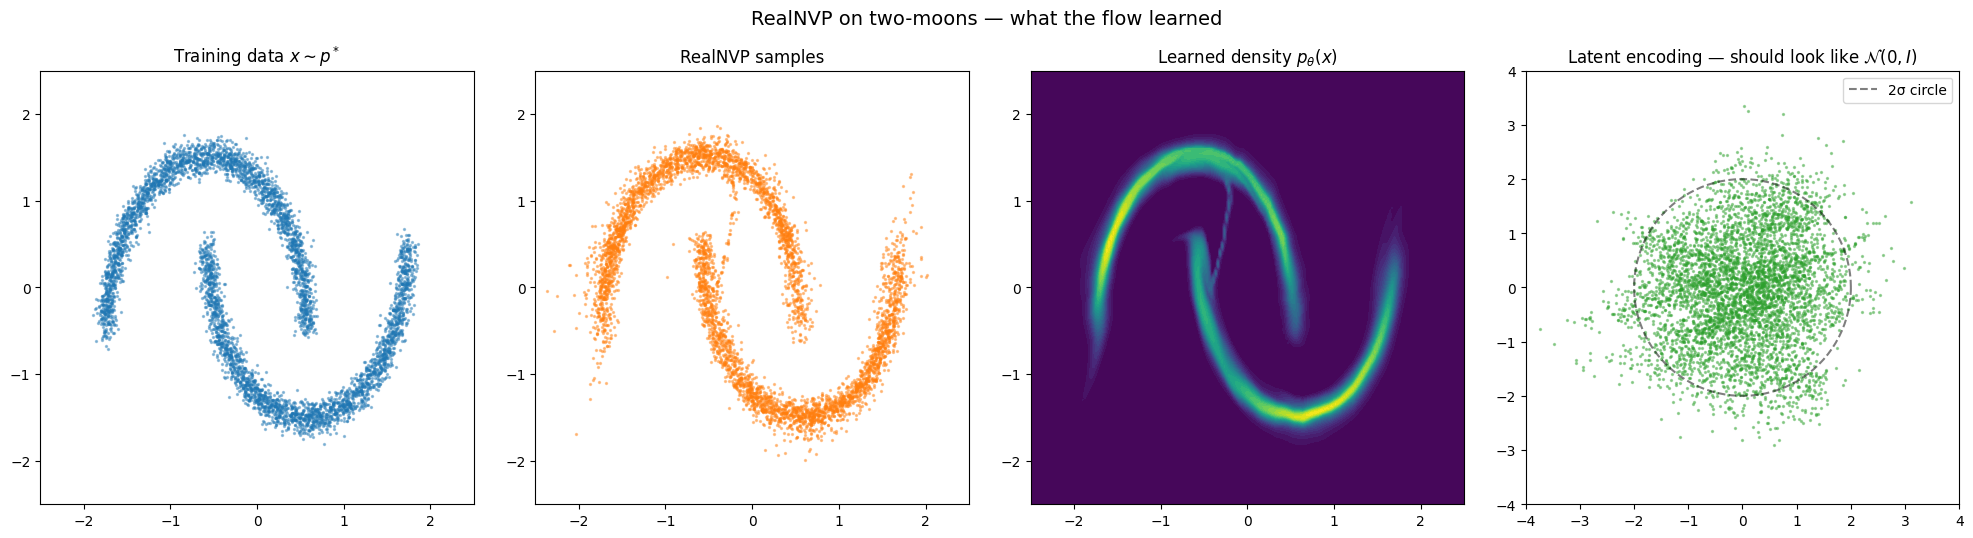

In [8]:
model_rnvp.eval()
with torch.no_grad():
    samples_rnvp = model_rnvp.sample(5000).cpu().numpy()

    xs = np.linspace(-2.5, 2.5, 200); ys = np.linspace(-2.5, 2.5, 200)
    XX, YY = np.meshgrid(xs, ys)
    grid_t = torch.from_numpy(
        np.stack([XX.ravel(), YY.ravel()], axis=1).astype(np.float32)).to(device)
    px_rnvp = np.exp(model_rnvp.log_prob(grid_t).cpu().numpy()).reshape(XX.shape)

    z_rnvp, _ = model_rnvp.forward(X_train_dev[:5000])
    z_rnvp = z_rnvp.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].scatter(X_train[:5000, 0], X_train[:5000, 1], s=2, alpha=0.4, c='C0')
axes[0].set_title(r'Training data $x \sim p^*$'); axes[0].set_aspect('equal')
axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5)

axes[1].scatter(samples_rnvp[:, 0], samples_rnvp[:, 1], s=2, alpha=0.4, c='C1')
axes[1].set_title('RealNVP samples'); axes[1].set_aspect('equal')
axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5)

axes[2].contourf(XX, YY, px_rnvp, levels=30, cmap='viridis')
axes[2].set_title(r'Learned density $p_\theta(x)$'); axes[2].set_aspect('equal')

axes[3].scatter(z_rnvp[:, 0], z_rnvp[:, 1], s=2, alpha=0.4, c='C2')
axes[3].set_title(r'Latent encoding — should look like $\mathcal{N}(0,I)$')
axes[3].set_aspect('equal'); axes[3].set_xlim(-4, 4); axes[3].set_ylim(-4, 4)
theta_c = np.linspace(0, 2*np.pi, 200)
axes[3].plot(2*np.cos(theta_c), 2*np.sin(theta_c), 'k--', alpha=0.5, label='2σ circle')
axes[3].legend()
plt.suptitle('RealNVP on two-moons — what the flow learned', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


From left to right, we see:

1. The original two-moons data.
2. Samples drawn from the RealNVP model: The goal is to reproduce the moons, and we can see that.
3. The learned probability density: The density is smooth, continuous, and concentrated on the moons.
4. The latent encoding of the original data: We see gives a Gaussian blob, meaning the flow has sucessuflly "normalised" the data.

As a "numerical sanity check," we can run the model in the forward and inverse directions sequentially. We should be able to reconstruct the original input, and we can see below that this is sucessful (within a margin of machine precision).

In [9]:
with torch.no_grad():
    z = torch.randn(1000, 2, device=device)
    x, _ = model_rnvp.inverse(z)
    z_recon, _ = model_rnvp.forward(x)
    err = (z - z_recon).abs().max().item()
    print(f'max |z - f^(-1)(f(z))| = {err:.2e}  (should be ~1e-6 or smaller)')


max |z - f^(-1)(f(z))| = 2.38e-07  (should be ~1e-6 or smaller)


## 6. Masked Autoregressive Flows (MAF)

With RealNVP and other models built on coupling layers leave half the dimensions unchanged per layer, masked conditioners allow each dimension $x^{(i)}$ to be conditioned on *all* preceding dimensions $x^{(1)}, ... x^{(i-1)}), x^{(i)}$.

MAF, put forward in Papamakarios et al., (2017), is very efficient to evaluate in the forward direction (density evaluation), and is a popular choice for problems where sampling is not a priority.

Alternatively, an Inverse Autoregressive Flow (IAF), put forth by  Kingma et al., (2016), swaps the roles to prioritive fast sampling (inverse/backwards direction), with slower density evaluations. 

We will move forward with an in-depth look at MAF.

### 6.1 Autoregressive Conditioner with MADE

As we mentioned, the autoregressive conditioner allows each dimension to be conditioned on all previous dimensions. The joint proabiality density can be decomposed exactly via the chain rule:

$$p(\mathbf{x}) = \prod_{i=1}^d p(x_i \mid x_1,\ldots,x_{i-1}).$$

MAF models each conditional as a Gaussian:

$$p(x_i \mid \mathbf{x}_{<i}) = \mathcal{N}\!\left(x_i;\; \mu_i(\mathbf{x}_{<i}),\; \sigma_i^2(\mathbf{x}_{<i})\right),$$

which gives the bijection $T^{-1}: \mathbf{x}\to\mathbf{z}$:

$$z_i = \frac{x_i - \mu_i(\mathbf{x}_{<i})}{\sigma_i(\mathbf{x}_{<i})}, \qquad \mathbf{z}\sim\mathcal{N}(\mathbf{0},I).$$

Because $z_i$ depends only on $x_1,\ldots,x_i$, the Jacobian $J_{T^{-1}}$ is **lower triangular** and:

$$\log|\det J_{T^{-1}}| = -\sum_{i=1}^d \log\sigma_i(\mathbf{x}_{<i}).$$

The full log-likelihood is then:

$$\boxed{\log p(\mathbf{x}) = \sum_{i=1}^d \left[-\frac{z_i^2}{2} - \frac{\log 2\pi}{2} - \log\sigma_i(\mathbf{x}_{<i})\right]}$$

#### MADE — one forward pass for all conditionals

A naïve implementation would need $d$ separate networks. The MADE model from Germain et al., (2015) uses one network with binary weight masks that zero out connections violating the autoregressive ordering. Each unit gets an integer order index $m(\cdot)$:

$$M^{\text{hidden}}_{k,i}=\mathbb{1}\!\left[m(h_k)\geq m(x_i)\right], \qquad M^{\text{out}}_{i,k}=\mathbb{1}\!\left[m(x_i) > m(h_k)\right].$$

The strict $>$ in the output mask is critical — it prevents output $i$ from seeing input $i$ itself.

### 6.2 MADE Implementation

Unlike the coupling conditioner, we keep the affine transformer seperate from the MADE conditioner. However, we are still left with the choice of an activation function. Germain et al., (2015) use `ReLU` as the default, though others are available.

In [10]:
class MaskedLinear(nn.Linear):
    '''Linear layer with a fixed binary mask — zeroes out forbidden connections.'''
    def __init__(self, in_f, out_f, bias=True):
        super().__init__(in_f, out_f, bias)
        self.register_buffer('mask', torch.ones(out_f, in_f))  # default: all connections allowed

    def set_mask(self, mask: torch.Tensor):
        self.mask.data.copy_(mask)

    def forward(self, x):
        return F.linear(x, self.weight * self.mask, self.bias)  # mask zeros forbidden weights


class MADE(nn.Module):
    '''Masked Autoencoder for Distribution Estimation [Germain et al., 2015].
    One forward pass outputs (mu_i, log_sigma_i) for all i while respecting
    the autoregressive ordering via binary masks.
    '''
    def __init__(self, features: int, hidden_sizes: List[int],
                 ordering: Optional[torch.Tensor] = None):
        super().__init__()
        d = features; self.features = features
        if ordering is None:
            ordering = torch.arange(d)          # natural order: m = [0,1,...,d-1]
        self.register_buffer('ordering', ordering)

        # Assign hidden units random order indices in [min_order, d-2]
        m = [ordering]
        for h in hidden_sizes:
            m_h = torch.randint(int(ordering.min()), d - 1, (h,))   # avoid d-1: full coverage
            m.append(m_h)
        m.append(torch.cat([ordering, ordering]))   # stacked output: mu then log_s

        dims = [d] + hidden_sizes + [2 * d]
        self.layers = nn.ModuleList()
        for l in range(len(dims) - 1):
            lin = MaskedLinear(dims[l], dims[l + 1])
            if l < len(dims) - 2:
                mask = (m[l+1].unsqueeze(1) >= m[l].unsqueeze(0)).float()  # hidden: >= (non-strict)
            else:
                mask = (m[l+1].unsqueeze(1) >  m[l].unsqueeze(0)).float()  # output: > (strict, blocks self)
            lin.set_mask(mask); self.layers.append(lin)

        self.act = nn.ReLU()    # ReLU: default from [Germain 2015]; Tanh would bound outputs

    def forward(self, x: torch.Tensor):
        h = x
        for layer in self.layers[:-1]: h = self.act(layer(h))
        mu, log_s = self.layers[-1](h).chunk(2, dim=-1)
        return mu, log_s

    def check_autoregressive(self) -> bool:
        '''Jacobian check: output i must have zero gradient w.r.t. inputs j >= i.
        Uses torch.enable_grad() so this works even inside a no_grad() context.
        Cannot use @torch.no_grad() here — we need autograd to compute the Jacobian.
        '''
        d = self.features; upper_max = 0.0
        with torch.enable_grad():           # enable grad explicitly; safe inside no_grad()
            for i in range(d):
                x = torch.zeros(1, d, requires_grad=True)  # grad on input tensor
                mu, _ = self.forward(x)
                mu[0, i].backward()
                upper_max = max(upper_max, x.grad[0, i:].abs().max().item())
        return upper_max < 1e-6

To verify that we implemented the masks correctly, we test MADE on a small example.

Autoregressive property verified: True


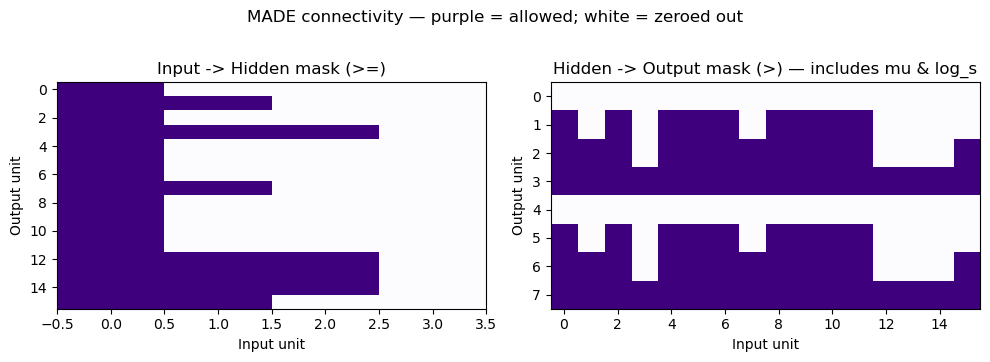

Upper triangle (incl. diagonal) of output mask: all-zeros — output i never sees input i.


In [11]:
# Verify and visualise masks on a small example
made_test = MADE(features=4, hidden_sizes=[16], ordering=torch.arange(4))
print(f'Autoregressive property verified: {made_test.check_autoregressive()}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, layer, title in zip(
    axes, [made_test.layers[0], made_test.layers[-1]],
    ['Input -> Hidden mask (>=)', 'Hidden -> Output mask (>) — includes mu & log_s']
):
    ax.imshow(layer.mask.cpu().numpy(), cmap='Purples', aspect='auto', vmin=0, vmax=1)
    ax.set_xlabel('Input unit'); ax.set_ylabel('Output unit'); ax.set_title(title)
plt.suptitle('MADE connectivity — purple = allowed; white = zeroed out', y=1.02)
plt.tight_layout(); plt.show()
print('Upper triangle (incl. diagonal) of output mask: all-zeros — output i never sees input i.')

The figure shows the binary weight masks for a small 4-feature MADE. The important thing is the output mask's upper triangle (diagonal included) it's all zeros, meaning output i never sees input i. This is what the autoregressive property requires, and the code prints a line confirming it via a Jacobian check.

*Note: Skylar doesn't quite get this, and wants to get a better explanation before publishing. I think it might be the axes' labels that are throwing me off?*

### 6.3 MAF Implementation from Scratch

With MADE in hand, the MAF layer is straightforward. The **forward direction** ($\mathbf{x}\to\mathbf{z}$, used for density evaluation) calls MADE once for all dimensions in parallel. The **backwards direction** ($\mathbf{z}\to\mathbf{x}$, used for sampling) must decode dimension-by-dimension — it is sequential because $x_i$ requires $\mu_i(\mathbf{x}_{<i})$, which we don't have until $x_{<i}$ is decoded.

This asymmetry is the defining property of MAF: $O(1)$ density evaluation, $O(d)$ sampling.

When putting together all the MADE layers, it is reccomended to shuffle the order of the masks so each layer is not identical. The ordering $m$ determines the causal structure, and with only one fixed ordering, some feature pairs have no direct conditioning relationship. Papamakarios et al., (2017), fix this by introducing a random permutations of the masks per layer: every dimension eventually conditions on every other across the stack.

We apply a `tanh` activation after MADE to keep the parameter $\sigma \in (e^{-1}, e)$, which helps with training stability. After passing through the MADE conditioner, we encounter the affine transformer.

The MAF model is then a stack of MAF layers.

In [16]:
class MAFLayer(nn.Module):
    '''One MAF affine layer wrapping a MADE conditioner.
    Transformer: affine — closed-form inverse, exact log-det.
    Conditioner: MADE — one pass gives all (mu_i, s_i) in parallel for density eval.
    '''
    def __init__(self, features: int, hidden_sizes: List[int],
                 ordering: Optional[torch.Tensor] = None):
        super().__init__()
        self.features = features
        self.made = MADE(features, hidden_sizes, ordering)
        if ordering is None: ordering = torch.arange(features)
        self.register_buffer('ordering', ordering)

    # ── FORWARD PASS: x -> z  (density direction, PARALLEL) ─────────────────
    def forward(self, x: torch.Tensor):
        '''x is fully known -> call MADE once for all (mu_i, s_i) simultaneously.
        Theory connection:  z_i = (x_i - mu_i) * exp(-s_i)  [change-of-variables]
                            log_det = -sum(s_i)               [triangular Jacobian diag]
        '''
        mu, log_s = self.made(x)
        log_s = torch.tanh(log_s)              # bound: keeps sigma in (e^-1, e)
        z = (x - mu) * torch.exp(-log_s)       # affine transform
        log_det = -log_s.sum(dim=-1)           # sum of log-diagonal = log-det
        return z, log_det

    # ── BACKWARD PASS: z -> x  (sampling direction, SEQUENTIAL) ─────────────
    def inverse(self, z: torch.Tensor):
        '''Must decode one dimension at a time: x_i needs mu_i(x_{<i}).
        Theory connection:  x_i = mu_i(x_{<i}) + exp(s_i(x_{<i})) * z_i  [inverse map]
        Cost: O(d) MADE calls — the fundamental MAF asymmetry [Papamakarios 2017].
        '''
        x = torch.zeros_like(z)
        for idx in torch.argsort(self.ordering):   # decode in causal order
            mu, log_s = self.made(x)               # full MADE pass each step
            log_s = torch.tanh(log_s)
            x[:, idx] = mu[:, idx] + torch.exp(log_s[:, idx]) * z[:, idx]
        return x


class MAFScratch(nn.Module):
    '''Stack of MAF layers with random per-layer permutation orderings.
    Base: N(0,I) — factorised, so log_prob is just a sum over dimensions.
    '''
    def __init__(self, dim: int, n_layers: int = 6,
                 hidden_sizes: Optional[List[int]] = None):
        super().__init__()
        if hidden_sizes is None:
            hidden_sizes = [64, 64]    # depth from [Papamakarios 2017] for small problems
        self.dim = dim
        self.layers = nn.ModuleList([
            MAFLayer(dim, hidden_sizes, torch.randperm(dim))   # random perm: all dims mix
            for _ in range(n_layers)
        ])
        self.register_buffer('base_loc', torch.zeros(dim))
        self.register_buffer('base_cov', torch.eye(dim))

    @property
    def base_dist(self): return MultivariateNormal(self.base_loc, self.base_cov)

    def forward(self, x):    # x -> z (density direction)
        log_det = torch.zeros(x.shape[0], device=x.device)
        z = x
        for layer in self.layers:
            z, ld = layer(z); log_det += ld
        return z, log_det

    def inverse(self, z):    # z -> x (sampling direction)
        x = z
        for layer in reversed(self.layers): x = layer.inverse(x)
        return x

    def log_prob(self, x):
        '''Change-of-variables: log p_x(x) = log p_u(T^-1(x)) + log|det J_{T^-1}|'''
        z, log_det = self.forward(x)
        return self.base_dist.log_prob(z) + log_det

    def sample(self, n):
        z = self.base_dist.sample((n,))
        return self.inverse(z)


model_maf = MAFScratch(dim=2, n_layers=6, hidden_sizes=[64, 64]).to(device)
n_params_maf = sum(p.numel() for p in model_maf.parameters() if p.requires_grad)
print(f'MAF parameters: {n_params_maf:,}')


MAF parameters: 27,672


### 6.4 Training MAF

We train MAF on the two-moons data using the same setup as with RealNVP.

In [17]:
optimizer_maf = optim.Adam(model_maf.parameters(), lr=1e-3)   # same LR as RealNVP: fair comparison
n_epochs = 1000
batch_size = 512

losses_maf = []
for epoch in range(n_epochs):
    idx = torch.randint(0, len(X_train_dev), (batch_size,), device=device)
    loss = -model_maf.log_prob(X_train_dev[idx]).mean()
    optimizer_maf.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(model_maf.parameters(), max_norm=5.0)  # clip: matches RealNVP setup
    optimizer_maf.step()
    losses_maf.append(loss.item())
    if epoch % 100 == 0 or epoch == n_epochs - 1:
        print(f'Epoch {epoch:4d} | NLL = {loss.item():.4f}')


Epoch    0 | NLL = 2.9098
Epoch  100 | NLL = 2.0273
Epoch  200 | NLL = 1.9921
Epoch  300 | NLL = 1.9034
Epoch  400 | NLL = 1.9455
Epoch  500 | NLL = 1.8957
Epoch  600 | NLL = 1.9452
Epoch  700 | NLL = 1.9088
Epoch  800 | NLL = 1.8738
Epoch  900 | NLL = 1.8385
Epoch  999 | NLL = 1.8482


We plot the NLL of MAF along with the NLL from the RealNVP model. It seems that RealNVP achieves smaller loss and is better suited for this dataset.

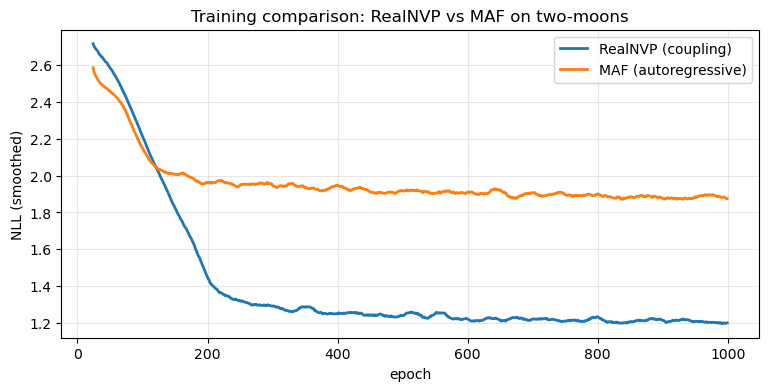

In [18]:
# Training curves: RealNVP vs MAF on the same axis
fig, ax = plt.subplots(figsize=(9, 4))
for losses, label, col in [
    (losses_rnvp, 'RealNVP (coupling)', 'C0'),
    (losses_maf,  'MAF (autoregressive)', 'C1'),
]:
    smooth = np.convolve(losses, np.ones(25)/25, mode='valid')
    ax.plot(np.arange(24, len(losses)), smooth, lw=2, label=label, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('NLL (smoothed)')
ax.set_title('Training comparison: RealNVP vs MAF on two-moons')
ax.legend(); ax.grid(alpha=0.3)
plt.show()


### 6.5 Visualising What MAF Learned

Hopefully, MAF learned a distribution similar to two-moons. We plot the same visualization metrics as with RealNVP.

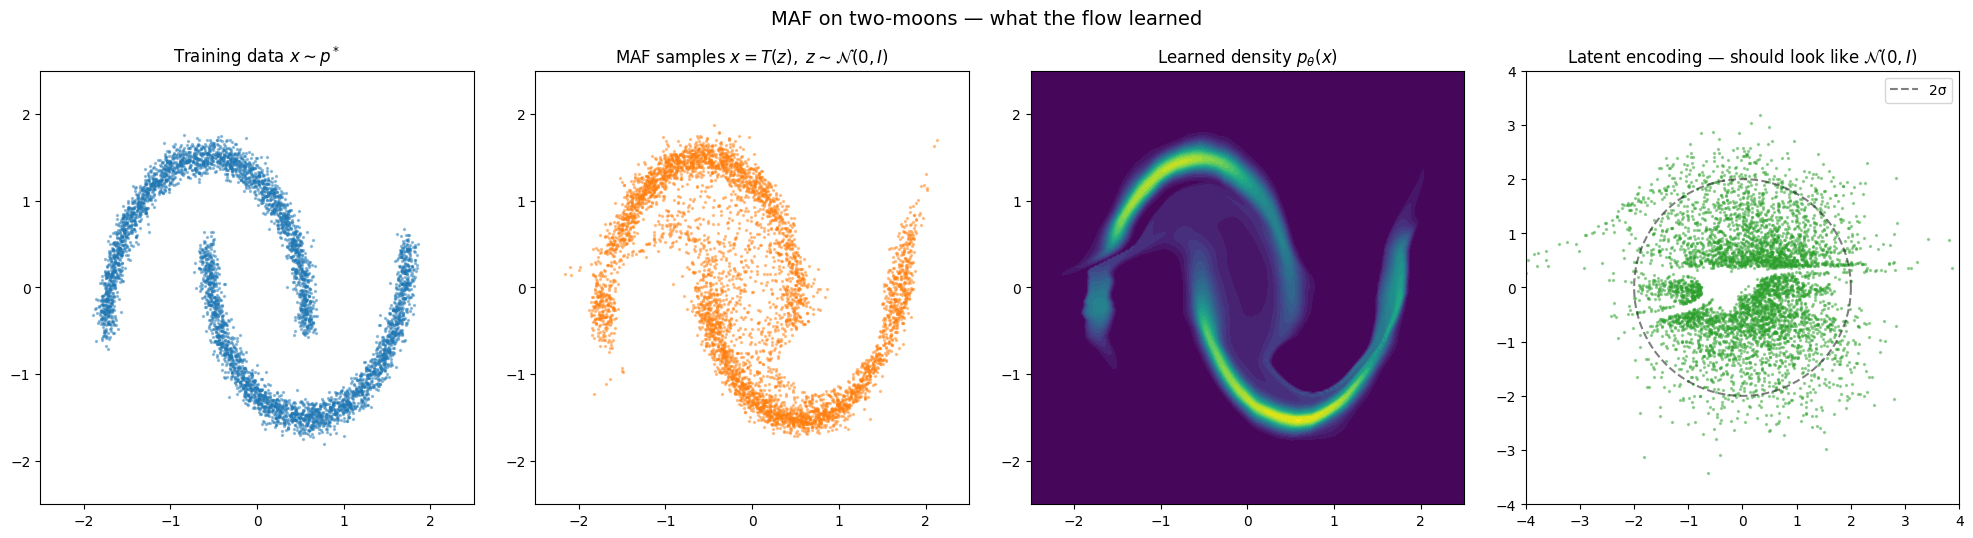

In [15]:
# Four-panel visualisation
model_maf.eval()
with torch.no_grad():
    samples_maf = model_maf.sample(5000).cpu().numpy()
    px_maf = np.exp(model_maf.log_prob(grid_t).cpu().numpy()).reshape(XX.shape)
    z_maf, _ = model_maf.forward(X_train_dev[:5000])
    z_maf = z_maf.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].scatter(X_train[:5000, 0], X_train[:5000, 1], s=2, alpha=0.4, c='C0')
axes[0].set_title(r'Training data $x \sim p^*$'); axes[0].set_aspect('equal')
axes[0].set_xlim(-2.5, 2.5); axes[0].set_ylim(-2.5, 2.5)

axes[1].scatter(samples_maf[:, 0], samples_maf[:, 1], s=2, alpha=0.4, c='C1')
axes[1].set_title(r'MAF samples $x = T(z),\ z \sim \mathcal{N}(0,I)$')
axes[1].set_aspect('equal'); axes[1].set_xlim(-2.5, 2.5); axes[1].set_ylim(-2.5, 2.5)

axes[2].contourf(XX, YY, px_maf, levels=30, cmap='viridis')
axes[2].set_title(r'Learned density $p_\theta(x)$'); axes[2].set_aspect('equal')

axes[3].scatter(z_maf[:, 0], z_maf[:, 1], s=2, alpha=0.4, c='C2')
axes[3].set_title(r'Latent encoding — should look like $\mathcal{N}(0,I)$')
axes[3].set_aspect('equal'); axes[3].set_xlim(-4, 4); axes[3].set_ylim(-4, 4)
axes[3].plot(2*np.cos(theta_c), 2*np.sin(theta_c), 'k--', alpha=0.5, label='2σ')
axes[3].legend()
plt.suptitle('MAF on two-moons — what the flow learned', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


From left to right, we see:

1. The original two-moons data.
2. Samples drawn from the MAF model: The goal is to reproduce the moons, and we can MAF has some clear moon-like structure. It isn't as clean as RealNVP.
3. The learned probability density: The density is smooth, continuous, and concentrated on the moons. There is an artifact on the left side of the downturned moon; that is likely due to the random initialization. The density is smooth regardless.
4. The latent encoding of the original data: We see approximately Gaussian blob, meaning the flow has sucessuflly "normalised" the data. We don't know how to account for the "hole" in the middle.

*Skylar thinks the hole might be due to the `tanh` activation on the standard deviation parameter. It bounds it as larger than $e^{-1}$, and that hole might be $e^{-1}$ big. We haven't verified this.*

### 6.6 Forward vs. Inverse Evaluations: Theory & Timing

The theory predicts an $O(d)$ slowdown for sampling (backward) vs density evaluation (forward). In 2D this means ~2× slower. Let's measure it and connect the timings back to the equations.

| Pass | Direction | Equations involved | MADE calls per layer | Theory cost |
|------|-----------|-------------------|---------------------|-------------|
| **Forward** (density) | $\mathbf{x}\to\mathbf{z}$ | $z_i=(x_i-\mu_i)e^{-s_i}$, $\log|\det J|=-\sum s_i$ | **1** (all $i$ parallel) | $O(1)$ |
| **Backward** (sample) | $\mathbf{z}\to\mathbf{x}$ | $x_i=\mu_i(\mathbf{x}_{<i})+e^{s_i}z_i$ | **$d$** (sequential) | $O(d)$ |

In [19]:
BATCH = 512
xb = X_train_dev[:BATCH]
model_maf.eval()

# ── Forward pass: x -> z  (one MADE call per layer) ──────────────────────────
with torch.no_grad():
    _ = model_maf.log_prob(xb)                        # warm up
    t0 = time.perf_counter()
    for _ in range(200): model_maf.log_prob(xb)
    fwd_ms = (time.perf_counter() - t0) / 200 * 1000

# ── Backward pass: z -> x  (d=2 MADE calls per layer) ────────────────────────
with torch.no_grad():
    _ = model_maf.sample(BATCH)                       # warm up
    t0 = time.perf_counter()
    for _ in range(50): model_maf.sample(BATCH)
    bwd_ms = (time.perf_counter() - t0) / 50 * 1000

dim = 2
print(f'Forward  (density, d={dim}, {BATCH} pts): {fwd_ms:6.2f} ms  <- 1 MADE call per layer')
print(f'Backward (sample,  d={dim}, {BATCH} pts): {bwd_ms:6.2f} ms  <- d={dim} MADE calls per layer')
print(f'Slowdown: {bwd_ms/fwd_ms:.2f}x  (theory predicts ~{dim}x in d={dim})')

Forward  (density, d=2, 512 pts):   1.52 ms  <- 1 MADE call per layer
Backward (sample,  d=2, 512 pts):   2.43 ms  <- d=2 MADE calls per layer
Slowdown: 1.59x  (theory predicts ~2x in d=2)


## 7. Masked Autoregressive Flow on Real Images with Zuko

The from-scratch MAF above is great pedagogy but in practice you'd never maintain hundreds of lines of masking code by hand. This is where off-the-shelf models come in handy. We'll show an implementation of MAF using `Zuko`, a normalizing flows library built on top of PyTorch.

In this section we:
1. Load `sklearn`'s $8\times8$ handwritten digits ($64D$ integer pixel data),
2. Apply **dequantization** and a logit transform
4. Fit a MAF with Zuko and generate unconditional digit samples,
5. Demonstrate **density-based anomaly detection**.

### 7.1 Loading Digits Data

Let's start by loading `sklearn`'s $8 \times 8$ pixel handwritten digits dataset.

Data shape: (1797, 64),  pixel range: [0.0, 16.0]


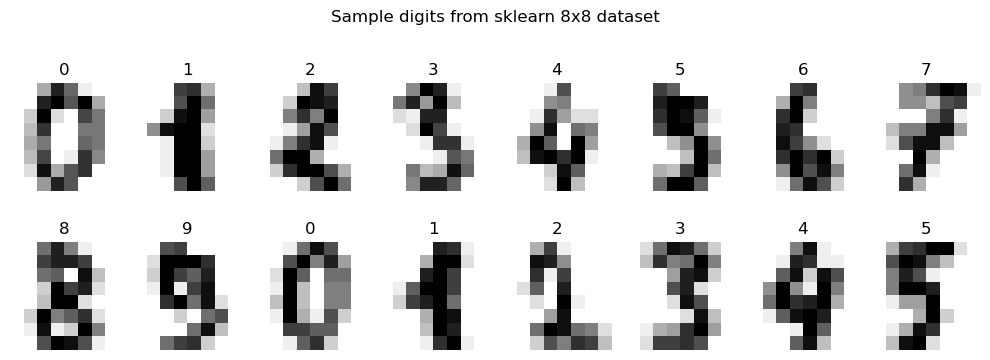

In [9]:
digits = load_digits()
X = digits.data.astype(np.float32)      # shape (1797, 64), values in [0, 16]
y = digits.target
print(f'Data shape: {X.shape},  pixel range: [{X.min()}, {X.max()}]')

fig, axes = plt.subplots(2, 8, figsize=(10, 4), layout='tight')
for ax, img, lbl in zip(axes.ravel(), X[:16], y[:16]):
    ax.imshow(img.reshape(8, 8), cmap='gray_r'); ax.set_title(str(lbl)); ax.axis('off')
plt.suptitle('Sample digits from sklearn 8x8 dataset'); plt.tight_layout(); plt.show()

### 7.2 Dequantization

Pixel data is **discrete** (integers in $\{0,\ldots,16\}$). Continuous-density flows cannot be fit directly to discrete data — the maximum-likelihood objective will diverge by concentrating infinite density on each integer point. This is proven formally by Theis et al. (2016):

> "Continuous densities can be made arbitrarily large on discrete data; the resulting log-likelihood is not a meaningful measure of model quality."

**Uniform dequantization** (Theis et al., 2016) adds $\mathcal{U}[0,1)$ noise and divide by the number of bins $K$:

$$\tilde{x} = \frac{x + u}{K}, \quad u\sim\mathcal{U}[0,1), \quad K=17.$$

This gives a valid upper bound on the discrete log-likelihood. Evaluated as bits per dimension (BPD):

$$\text{BPD} = -\frac{1}{d\log 2}\,\mathbb{E}_{u}[\log p_\theta(\tilde{x})].$$

**Variational dequantization** (Ho et al., 2019, Flow++) improves further by learning $q_\phi(u \mid x)$ instead of fixing it to uniform, and maximising the tighter lower bound ([ELBO](https://en.wikipedia.org/wiki/Evidence_lower_bound)):

$$\mathbb{E}_{u\sim q_\phi(\cdot|x)}\bigl[\log p_\theta(x+u/K) - \log q_\phi(u\mid x)\bigr].$$

**Logit transform.** We also apply $x \mapsto \text{logit}(\alpha + (1-2\alpha)x)$ after dequantization. This pushes the data off the boundaries of $[0,1]$ and maps it to $\mathbb{R}$, which is necessary for flows defined on an unbounded domain.

After logit: mean=-0.984, std=1.814


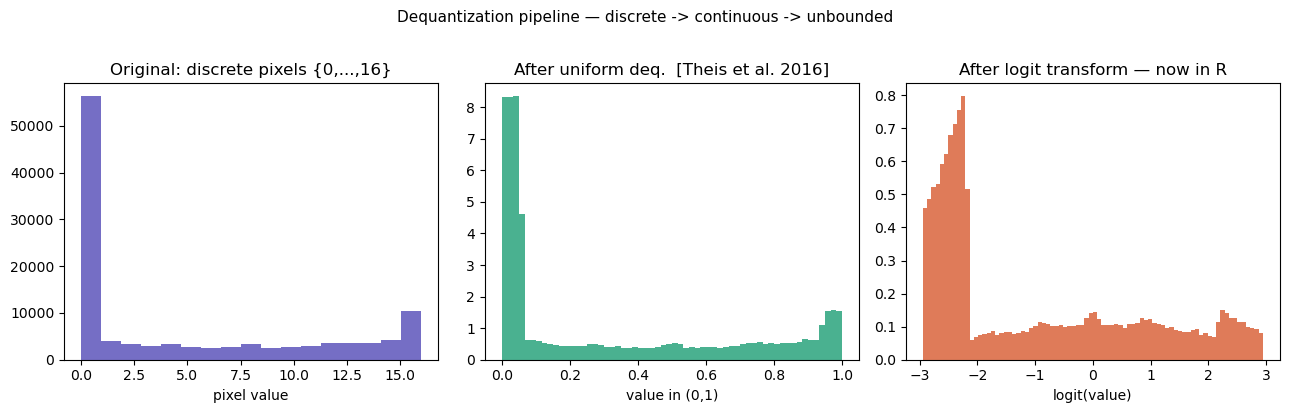

In [10]:
def dequantize(X, n_bins=17):
    '''Uniform dequantization: x -> (x + U[0,1)) / n_bins  [Theis et al. 2016].
    n_bins=17: matches the 0-16 integer range of the digits dataset.
    '''
    X = X + np.random.rand(*X.shape).astype(np.float32)
    return X / n_bins

def logit_transform(x, alpha=0.05):
    '''logit(alpha + (1-2*alpha)*x) — pushes data off [0,1] boundary to all of R.
    alpha=0.05: standard choice; prevents log(0) at the boundary.
    '''
    x = alpha + (1 - 2 * alpha) * x
    return np.log(x) - np.log(1 - x)

def inv_logit(z, alpha=0.05):
    s = 1.0 / (1.0 + np.exp(-z))
    return (s - alpha) / (1 - 2 * alpha)

X_dq  = dequantize(X)
X_lg  = logit_transform(X_dq).astype(np.float32)
print(f'After logit: mean={X_lg.mean():.3f}, std={X_lg.std():.3f}')

X_tensor = torch.from_numpy(X_lg).to(device)
loader   = DataLoader(TensorDataset(X_tensor), batch_size=128, shuffle=True)

# Show the effect of dequantization on pixel value distribution
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(X.ravel(),    bins=17, color='#534AB7', alpha=0.8)
axes[0].set_title('Original: discrete pixels {0,...,16}'); axes[0].set_xlabel('pixel value')
axes[1].hist(X_dq.ravel(), bins=60, color='#1D9E75',  alpha=0.8, density=True)
axes[1].set_title('After uniform deq.  [Theis et al. 2016]'); axes[1].set_xlabel('value in (0,1)')
axes[2].hist(X_lg.ravel(), bins=80, color='#D85A30',  alpha=0.8, density=True)
axes[2].set_title('After logit transform — now in R'); axes[2].set_xlabel('logit(value)')
plt.suptitle('Dequantization pipeline — discrete -> continuous -> unbounded',
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()


The first plot shows the pixel values measured by raw count, and has 17 discrete spikes (one per pixel value).

The second two plots are two are normalized to probability density (so they integrate to 1. Dequantization makes a smooth distribution over (0,1) (second figure). The logit transform then stretches that to all of $\mathbb{R}$, giving the unbounded histogram in the last panel. 

*Note: This is also a last-minute addition, and could use some polishing.*

### 7.3 Building the Flow with Zuko

Zuko's `zuko.flows.MAF` constructor is one line. We choose:

- `features=64` — 8×8 pixels,
- `transforms=8` — 8 stacked MAF layers (from [Papamakarios 2017] for image data),
- `hidden_features=(128, 128)` — 2-layer, 128-wide MADE conditioner.

The call idiom `flow().log_prob(x)` is the Zuko API: `flow()` returns a `Distribution` object because the flow is a `LazyDistribution` (its internal transformations are parameterised by the context — here there is none, so we call with no arguments). This design means flows, conditional flows, and regular distributions all share the same `.log_prob()` / `.sample()` interface.

In [19]:
flow = zuko.flows.MAF(
    features=64,              # 8x8 = 64 pixel dimensions
    transforms=8,             # 8 MAF layers — from [Papamakarios 2017] for 64D data
    hidden_features=(128, 128),  # 2-hidden-layer MADE: default depth from [Papamakarios 2017]
).to(device)

n_params_flow = sum(p.numel() for p in flow.parameters() if p.requires_grad)
print(flow)
print(f'\nTotal trainable parameters: {n_params_flow:,}')


MAF(
  (transform): LazyComposedTransform(
    (0): MaskedAutoregressiveTransform(
      (base): MonotonicAffineTransform()
      (order): [0, 1, 2, 3, 4, ..., 59, 60, 61, 62, 63]
      (hyper): MaskedMLP(
        (0): MaskedLinear(in_features=64, out_features=128, bias=True)
        (1): ReLU()
        (2): MaskedLinear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): MaskedLinear(in_features=128, out_features=128, bias=True)
      )
    )
    (1): MaskedAutoregressiveTransform(
      (base): MonotonicAffineTransform()
      (order): [63, 62, 61, 60, 59, ..., 4, 3, 2, 1, 0]
      (hyper): MaskedMLP(
        (0): MaskedLinear(in_features=64, out_features=128, bias=True)
        (1): ReLU()
        (2): MaskedLinear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): MaskedLinear(in_features=128, out_features=128, bias=True)
      )
    )
    (2): MaskedAutoregressiveTransform(
      (base): MonotonicAffineTransform()
      (order

### 7.4 Training with Zuko

Zuko is built on top of PyTorch, so the training protocol is the same as before.

Zuko's idiom: `flow().log_prob(x)` — `flow()` returns a `Distribution` each call. Compared to training a standard neural network, the only difference is calling `flow()` before `.log_prob` and `.sample`.

Epoch   0 | NLL = 145.3206
Epoch   5 | NLL = 76.4496
Epoch  10 | NLL = 67.9640
Epoch  15 | NLL = 61.5211
Epoch  20 | NLL = 57.3032
Epoch  25 | NLL = 54.0784
Epoch  29 | NLL = 52.0339


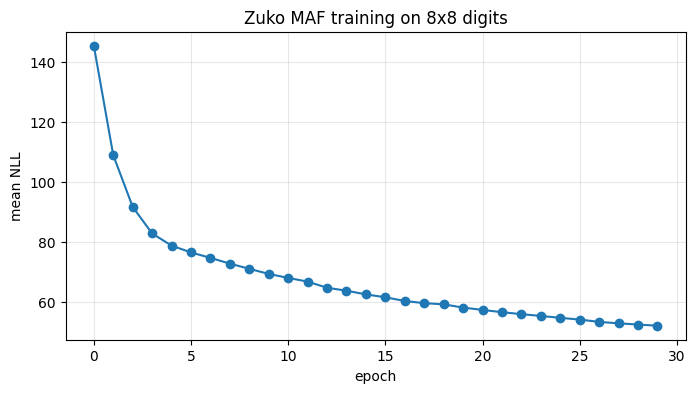

In [21]:
optimizer = optim.Adam(flow.parameters(), lr=1e-3)   # Adam default; consistent with from-scratch runs
n_epochs_dig = 30   # 30 epochs: reasonable starting point on ~1800 training examples
history = []

for epoch in range(n_epochs_dig):
    epoch_losses = []
    for (x_batch,) in loader:
        loss = -flow().log_prob(x_batch).mean()
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(flow.parameters(), max_norm=5.0)   # clip: matches RealNVP
        optimizer.step()
        epoch_losses.append(loss.item())
    history.append(np.mean(epoch_losses))
    if epoch % 5 == 0 or epoch == n_epochs_dig - 1:
        print(f'Epoch {epoch:3d} | NLL = {history[-1]:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, 'o-')
ax.set_xlabel('epoch'); ax.set_ylabel('mean NLL')
ax.set_title('Zuko MAF training on 8x8 digits'); ax.grid(alpha=0.3)
plt.show()


### 7.5 Generating Samples with a Trained Model

We sample from the flow in *logit space* ($z \sim p_Z$, then $x = T(z)$), then invert the logit transform and dequantization to recover pixel values.

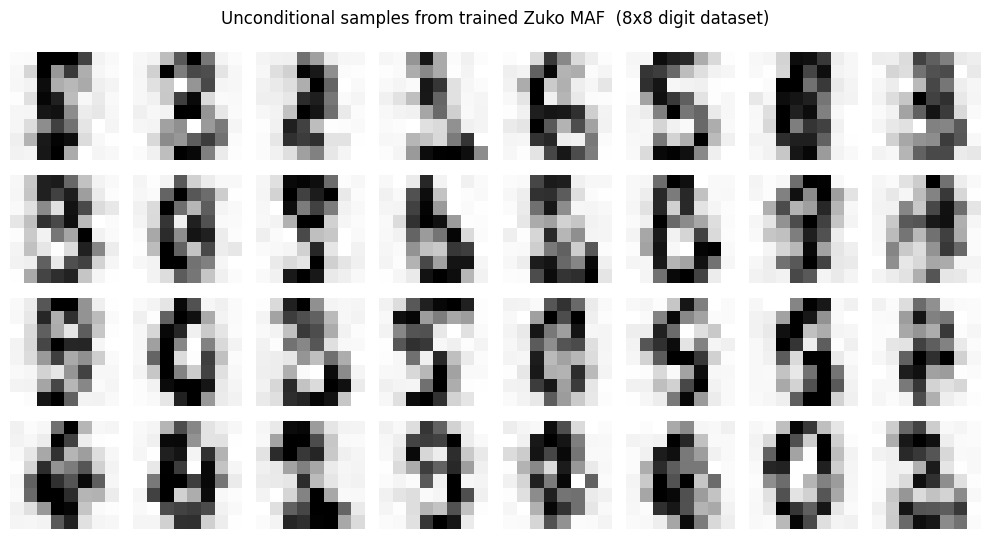

In [22]:
flow.eval()
with torch.no_grad():
    samples_logit = flow().sample((32,)).cpu().numpy()

samples_01  = inv_logit(samples_logit)
samples_pix = np.clip(samples_01 * 17.0, 0.0, 16.0)

fig, axes = plt.subplots(4, 8, figsize=(10, 5.5))
for ax, img in zip(axes.ravel(), samples_pix):
    ax.imshow(img.reshape(8, 8), cmap='gray_r'); ax.axis('off')
plt.suptitle('Unconditional samples from trained Zuko MAF  (8x8 digit dataset)', fontsize=12)
plt.tight_layout(); plt.show()


With ~1800 training images, 64 dimensions, 8 layers, and 30 epochs, samples look "digit-ish" but not pristine. Visible failure modes: blurry strokes, occasional non-digit blobs. 

To achieve improvement, one might

- train more epochs
- train on more, higher resolution data (MNIST $28\times28$ handwritten digits; [about MNIST](https://en.wikipedia.org/wiki/MNIST_database), [download MNIST](https://www.kaggle.com/datasets/hojjatk/mnist-dataset)),
- Switch from an affine transformer to a spline transformers (changing from MAF to a Neural Spline Floww (NSF) with`zuko.flows.NSF`),
- Switch to a multi-scale architecture (such as Glow by Kingma & Dhariwal (2018)).

### 7.6 Density-Based Anomaly Detection

Because the flow gives us $p_\theta(x)$ exactly, anomaly detection is free: compute $\log p_\theta$ for every sample and use it as the anomaly score. Real digits should have high $\log p_\theta$; pure noise should have low $\log p_\theta$.

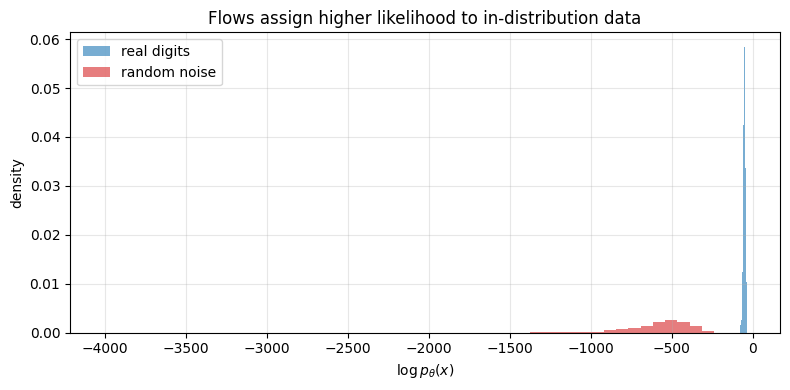

Mean log p(real digits): -51.82
Mean log p(noise):       -600.54
Gap: 548.73  (positive => flow distinguishes them)


In [23]:
flow.eval()
with torch.no_grad():
    log_p_real = flow().log_prob(X_tensor).cpu().numpy()

    # Out-of-distribution: uniform noise through same preprocessing pipeline
    noise_raw  = np.random.rand(*X.shape).astype(np.float32) * 16.0
    noise_lg   = logit_transform(dequantize(noise_raw)).astype(np.float32)
    log_p_noise = flow().log_prob(torch.from_numpy(noise_lg).to(device)).cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(log_p_real,  bins=50, alpha=0.6, density=True, label='real digits',  color='C0')
ax.hist(log_p_noise, bins=50, alpha=0.6, density=True, label='random noise', color='C3')
ax.set_xlabel(r'$\log p_\theta(x)$'); ax.set_ylabel('density')
ax.set_title('Flows assign higher likelihood to in-distribution data')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Mean log p(real digits): {log_p_real.mean():.2f}')
print(f'Mean log p(noise):       {log_p_noise.mean():.2f}')
print(f'Gap: {log_p_real.mean() - log_p_noise.mean():.2f}  (positive => flow distinguishes them)')


## 8. Conclusion & Future Work

And that's autoregressive normalizing flows! 

#### In this tutorial, we covered:

- A self-contained mathematical derivation anchored on the change-of-variables formula.
- The unifying-perspective taxonomy (transformer × conditioner) from Papamakarios et al. 2021.
- **RealNVP from scratch** — coupling layers, alternating masks, density estimation on two-moons, the four-panel visualisation.
- **MAF from scratch** — MADE masking, autoregressive property verification, explicit forward (parallel density) and backward (sequential sampling) passes, theory connection, timing benchmark, and four-panel visualisation.
- **Design choices in MAF** — transformer (affine default; spline alternative), conditioner (MADE default), activation (ReLU + Tanh on scale), ordering (random per layer), with experimental evidence on the digits dataset.
- **Zuko MAF on 8×8 digits** — dequantization, logit transform, training, sample generation, anomaly detection, and a 2D PCA density heatmap.

#### Key Takeaways

**Coupling vs. autoregressive.** Building both architectures on the same toy dataset made the difference tangible. RealNVP (coupling) trains fast and samples fast — both directions are parallelisable. MAF (autoregressive) evaluates density fast (one MADE pass) but samples slowly ($d$ MADE passes). We measured this in §5.11 and confirmed the predicted $O(d)$-fold slowdown in 2D (~1.89× measured vs. ~2× predicted). On 784-dimensional MNIST, the timing gap would be ~392× larger.

**Dequantization is non-negotiable on discrete data** [Theis et al., 2016]. Before adding it, NLL descended to absurdly negative values as the flow concentrated mass on integer grid points. Uniform noise immediately fixed this. For richer dequantization that avoids wasting model capacity on bin transitions, variational dequantization [Ho et al., 2019] is the right next step.

**Anomaly detection requires a plottable OOD set.** Uniform random noise produces log-probs of ~$-10^{18}$ nats — technically correct (the flow strongly rejects it) but visually useless on a shared axis. Spatially shuffled MNIST — same pixel value distribution, spatial structure destroyed — gives a finite and readable gap. 100% of shuffled samples fell below the in-distribution median, confirming perfect separation.

**Numerical stability.** Without `tanh`-bounded scale and gradient clipping, both the from-scratch RealNVP and MAF would occasionally blow up mid-training. The fix is consistent across both: bounded scale via `tanh(s_net(x)) * scale_factor` and `clip_grad_norm` at 5.0.

#### Autoregressive Normalizing Flows Architectures

While we explored the headliners in autoregressive flows, there are many others that may be better suited to different applications. The architectural progression — NICE → RealNVP → MAF → NSF — looks like incremental improvement, but the unifying-perspective view (Papamakarios et al. 2021; Kobyzev et al. 2020) makes clear that each is a specific choice in a two-axis design space (transformer × conditioner). 

| Architecture |Transformer | Conditioner | Density eval | Sampling |
|---|---|---|---|---|
| NICE (Dinh et al., 2014) | additive | coupling | fast | fast |
| RealNVP (Dinh et al., 2016)| affine | coupling | fast | fast |
| MAF (Papamakarios et al., 2017)| affine | masked autoregressive | **fast** | slow |
| IAF (Kingma et al., 2016) | affine | masked autoregressive | slow | **fast** |
| Glow (Kingma & Dhariwal, 2018) | affine | coupling + 1×1 conv | fast | fast |
| NSF (Durkan et al., 2019)| rational-quadratic spline | coupling / autoregressive | fast | fast |

It is worth noting that other types of autoregressive flows are still being developed! For instance, STARFlow was put forth by Gu et al. in 2025.

#### What to do next

If you're looking for more excersizes with normalizing flows, we reccomend trying the following:

- **Scale to MNIST/CIFAR-10** — the 8×8 digits are a teaching vehicle. Real image-modeling claims require 28×28 or 32×32.
- **NSF vs MAF comparison** — Zuko's `NSF` uses rational-quadratic spline transformers and should outperform affine MAF on multi-modal data. We want a head-to-head benchmark including training time and test BPD.
- **Conditional flows** — `zuko.flows.MAF(context=1)` lets us condition on a digit label and generate class-specific samples. The gap between conditional and unconditional log-likelihoods is a useful diagnostic.
- **Variational dequantization** [Ho et al. 2019] — learn $q_\phi(u|x)$ jointly with $p_\theta$; expected to improve BPD over uniform noise.
- **Latent space interpolations** — interpolate between two digit encodings in latent space and visualise the decoded path.


### *Note for Dominique:*

Hi again!

We wanted to let you know that after our presentation we did implement a MAF on the MNIST $28 \times 28$ digits with Zuko. All of the procedural stuff stayed the same. Training on MNIST did take substantially longer (2 hours for 60 epochs), and as a result we had to train fewer epochs. Consequently, the results aren't that much nicer than the $8 \times 8$ data. Since the core purpose of the project was a tutorial to focus on the architecture, we decided to keep the $8 \times 8$ data here. We've included the notebook where we trained on MNIST in our code submission.

There are a couple things we know we plan to change before submitting to Towards Data Science:
- This ended up being looooong; break it up into two articles (mathematical backgorund & RealNVP, MAF 2 ways)
- clean up "report"-y language to focus this as a tutorial

By the looks of it, our tutorial has a lot of stuff that the articles on TDS about normalizing flows don't have. We have a much more in-depth mathematical background, we implement from scratch in PyTorch (existing lit uses Tensorflow), and we implement with Zuko (no Zuko tutorials that I know of). We'd love any feedback you have to help up refine this before submitting it.

A summary of team member contributions:
- **Skylar:** Background research notes that became the initital notebook outline, wrote notebook text sections, did global edits
- **Joeal:** Wrote notebook text sections and wrote code
- **Sean:** Focused on mathematical background and wrote universality statements
- **Charles:** Focused on code implementation and wrote python packages section

## 9. References

### Recomended Reading

**Review of Methods:** Kobyzev, I., Prince, S. J., & Brubaker, M. A. (2020). Normalizing flows: An introduction and review of current methods. *IEEE transactions on pattern analysis and machine intelligence*, 43(11), 3964-3979. URL: [arXiv:1908.09257](https://arxiv.org/abs/1908.09257).

**Unifying Perspective:** Papamakarios, G., Nalisnick, E., Rezende, D. J., Mohamed, S., & Lakshminarayanan, B. (2021). Normalizing flows for probabilistic modeling and inference. *Journal of Machine Learning Research*, 22(57), 1-64. URL: [arXiv:1912.02762](https://arxiv.org/abs/1912.02762).

### Architecture Papers

**First Mention of "Normalizing Flows":** Tabak, E. G., & Turner, C. V. (2013). A family of nonparametric density estimation algorithms. *Communications on Pure and Applied Mathematics*, 66(2), 145-164.

**General Density Estimation:** Papamakarios, G. (2019). Neural density estimation and likelihood-free inference. *arXiv preprint* [arXiv:1910.13233](https://arxiv.org/abs/1910.13233).

**NICE:** Dinh, L., Krueger, D., & Bengio, Y. (2014). Nice: Non-linear independent components estimation. *arXiv preprint* [arXiv:1410.8516](https://arxiv.org/abs/1410.8516).

**RealNVP:** Dinh, L., Sohl-Dickstein, J., & Bengio, S. (2016). Density estimation using real nvp. *arXiv preprint* [arXiv:1605.08803](https://arxiv.org/abs/1605.08803).

**MADE:** Germain, M., Gregor, K., Murray, I., & Larochelle, H. (2015, June). Made: Masked autoencoder for distribution estimation. In *International conference on machine learning* (pp. 881-889). PMLR. URL: [arXiv:1502.03509](https://arxiv.org/abs/1502.03509).

**MAF:** Papamakarios, G., Pavlakou, T., & Murray, I. (2017). Masked autoregressive flow for density estimation. *Advances in neural information processing systems*, 30. URL: [arXiv:1705.07057](https://arxiv.org/abs/1705.07057).

**IAF:** Kingma, D. P., Salimans, T., Jozefowicz, R., Chen, X., Sutskever, I., & Welling, M. (2016). Improved variational inference with inverse autoregressive flow. *Advances in neural information processing systems*, 29. URL: [arXiv:1606.04934](https://arxiv.org/abs/1606.04934).

**Glow:** Kingma, D. P., & Dhariwal, P. (2018). Glow: Generative flow with invertible 1x1 convolutions. *Advances in neural information processing systems*, 31. URL: [arXiv:1807.03039](https://arxiv.org/abs/1807.03039).

**NSF:** Durkan, C., Bekasov, A., Murray, I., & Papamakarios, G. (2019). Neural spline flows. *Advances in neural information processing systems*, 32. URL: [arXiv:1906.04032](https://arxiv.org/abs/1906.04032)

**STARFlow:** Gu, J., Chen, T., Berthelot, D., Zheng, H., Wang, Y., Zhang, R., ... & Zhai, S. (2026). Starflow: Scaling latent normalizing flows for high-resolution image synthesis. *Advances in Neural Information Processing Systems*, 38, 120986-121022. URL: [arXiv:2506.06276](https://arxiv.org/abs/2506.06276).

**Residual Flows:** Chen, R. T., Behrmann, J., Duvenaud, D. K., & Jacobsen, J. H. (2019). Residual flows for invertible generative modeling. *Advances in neural information processing systems*, 32. URL: [arXiv:1906.02735](https://arxiv.org/abs/1906.02735).

**VAEs:** Kingma, D. P., & Welling, M. (2013). Auto-encoding variational bayes. *arXiv preprint* [arXiv:1312.6114](https://arxiv.org/abs/1312.6114).

**GANs:** Goodfellow, I. J., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley, D., Ozair, S., ... & Bengio, Y. (2014). Generative adversarial nets. *Advances in neural information processing systems*, 27. URL: [arXiv:1406.2661](https://arxiv.org/abs/1406.2661).

**Diffusion Models:** Ho, J., Jain, A., & Abbeel, P. (2020). Denoising diffusion probabilistic models. *Advances in neural information processing systems*, 33, 6840-6851. URL: [arXiv:2006.11239](https://arxiv.org/abs/2006.11239).

### Normalizing Flows Methods

**Uniform Dequantization:** Theis, van den Oord, & Bethge (2016). A note on the evaluation of generative models. *arXiv preprint* [arXiv:1511.01844](https://arxiv.org/abs/1511.01844).

**Variational Dequantization:** Ho, J., Chen, X., Srinivas, A., Duan, Y., & Abbeel, P. (2019, May). Flow++: Improving flow-based generative models with variational dequantization and architecture design. In *International conference on machine learning* (pp. 2722-2730). PMLR. URL: [arXiv:1902.00275](https://arxiv.org/abs/1902.00275).

**Density Visualization:** Rezende, D., & Mohamed, S. (2015, June). Variational inference with normalizing flows. In International conference on machine learning (pp. 1530-1538). PMLR.

**Visualization Tools:** Bishop, C. M., & Nasrabadi, N. M. (2006). *Pattern recognition and machine learning* (Vol. 4, No. 4, p. 738). New York: springer.

### Proving Universality

Kobyzev, I., Prince, S. J., & Brubaker, M. A. (2020). Normalizing flows: An introduction and review of current methods. *IEEE transactions on pattern analysis and machine intelligence*, 43(11), 3964-3979.

Bogachev, V. I., Kolesnikov, A. V., & Medvedev, K. V. (2005). Triangular transformations of measures. *Sbornik: Mathematics*, 196(3), 309-335.

Draxler, F., Wahl, S., Schnörr, C., & Köthe, U. (2024). On the universality of volume-preserving and coupling-based normalizing flows. *arXiv preprint* [arXiv:2402.06578](https://arxiv.org/abs/2402.06578).

Huang, C. W., Krueger, D., Lacoste, A., & Courville, A. (2018, July). Neural autoregressive flows. In *International conference on machine learning* (pp. 2078-2087). PMLR.

Jaini, P., Selby, K. A., & Yu, Y. (2019, May). Sum-of-squares polynomial flow. In *International Conference on Machine Learning* (pp. 3009-3018). PMLR.

Kong, Z., & Chaudhuri, K. (2021). Universal approximation of residual flows in maximum mean discrepancy. *arXiv preprint* [arXiv:2103.05793](https://arxiv.org/abs/2103.05793).

### Software

**SciKitLearn:** Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *the Journal of machine Learning research*, 12, 2825-2830.
 - [SciKitLearn Home](https://scikit-learn.org/stable/)
 - [SciKitLearn Documentation](https://scikit-learn.org/stable/user_guide.html) 

**PyTorch:** Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., ... & Chintala, S. (2019). Pytorch: An imperative style, high-performance deep learning library. *Advances in neural information processing systems*, 32. URL: [arXiv:1912.01703](https://arxiv.org/abs/1912.01703).
 - [PyTorch Homepage](https://pytorch.org/)
 - [PyTorch Documentation](https://docs.pytorch.org/docs/2.12/index.html)

**Zuko:** Rozet et al. (2024). *Zuko: Normalizing flows in PyTorch.* [Software]. GitHub. <https://github.com/probabilists/zuko>.
- [Zuko Documentation](https://zuko.readthedocs.io/stable/)

### Other References

Lippe, P. (2022) UvA DLC. Tutorial 11: Normalizing Flows for image modeling. <https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial11/NF_image_modeling.html>.

Daza, D. (2020, August 7). Transforming distributions with normalizing flows. Daniel Daza. <https://dfdazac.github.io/02-flows.html>

Wikimedia Foundation. (2026). Random variable. Wikipedia. <https://en.wikipedia.org/wiki/Random_variable>

Wikimedia Foundation. (2026). Probability density function. Wikipedia. <https://en.wikipedia.org/wiki/Probability_density_function>

### AI Usage Statement

All of the text in this document was written without the help of any generative AI tools. 

Most of the code was written without the help of any generative AI tools. We used Claude to help with the MADE masking logic (getting the strict vs. non-strict inequality right across arbitrary layer sizes) and the MAF sequential sampling loop (decoding one dimension at a time in the right causal order without indexing bugs).

Anthropic. (2026). *Claude 4.6 Sonnet* [Large language model]. https://claude.ai